In [8]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\anubh\OneDrive\Desktop\AI-medical-assistant\data\anemia\anemia_classification.csv")

In [3]:
df.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   object 
dtypes: float64(14), object(1)
memory usage: 150.2+ KB


In [5]:
df['Diagnosis'].value_counts()

Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11
Name: count, dtype: int64

In [6]:
print("Missing values :", df.isnull().sum().sum())

Missing values : 0


In [9]:


le = LabelEncoder()
df["Diagnosis_enc"] = le.fit_transform(df["Diagnosis"])
 
print("\nLabel mapping:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {idx} → {cls}")
 
X = df.drop(["Diagnosis", "Diagnosis_enc"], axis=1)
y = df["Diagnosis_enc"]
 
# Scale features — important for distance-sensitive RF splits
scaler    = StandardScaler()
X_scaled  = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


Label mapping:
  0 → Healthy
  1 → Iron deficiency anemia
  2 → Leukemia
  3 → Leukemia with thrombocytopenia
  4 → Macrocytic anemia
  5 → Normocytic hypochromic anemia
  6 → Normocytic normochromic anemia
  7 → Other microcytic anemia
  8 → Thrombocytopenia



── Feature Statistics ──────────────────────────────────
           WBC     LYMp    NEUTp     LYMn    NEUTn      RBC      HGB      HCT  \
count  1281.00  1281.00  1281.00  1281.00  1281.00  1281.00  1281.00  1281.00   
mean      7.86    25.84    77.51     1.88     5.14     4.71    12.18    46.15   
std       3.56     7.04   147.75     1.34     2.87     2.82     3.81   104.89   
min       0.80     6.20     0.70     0.20     0.50     1.36   -10.00     2.00   
25%       6.00    25.84    71.10     1.88     5.10     4.19    10.80    39.20   
50%       7.40    25.84    77.51     1.88     5.14     4.60    12.30    46.15   
75%       8.68    25.84    77.51     1.88     5.14     5.10    13.50    46.15   
max      45.70    91.40  5317.00    41.80    79.00    90.80    87.10  3715.00   

           MCV      MCH     MCHC      PLT      PDW      PCT  
count  1281.00  1281.00  1281.00  1281.00  1281.00  1281.00  
mean     85.79    32.08    31.74   229.98    14.31     0.26  
std      27.18   111.17   

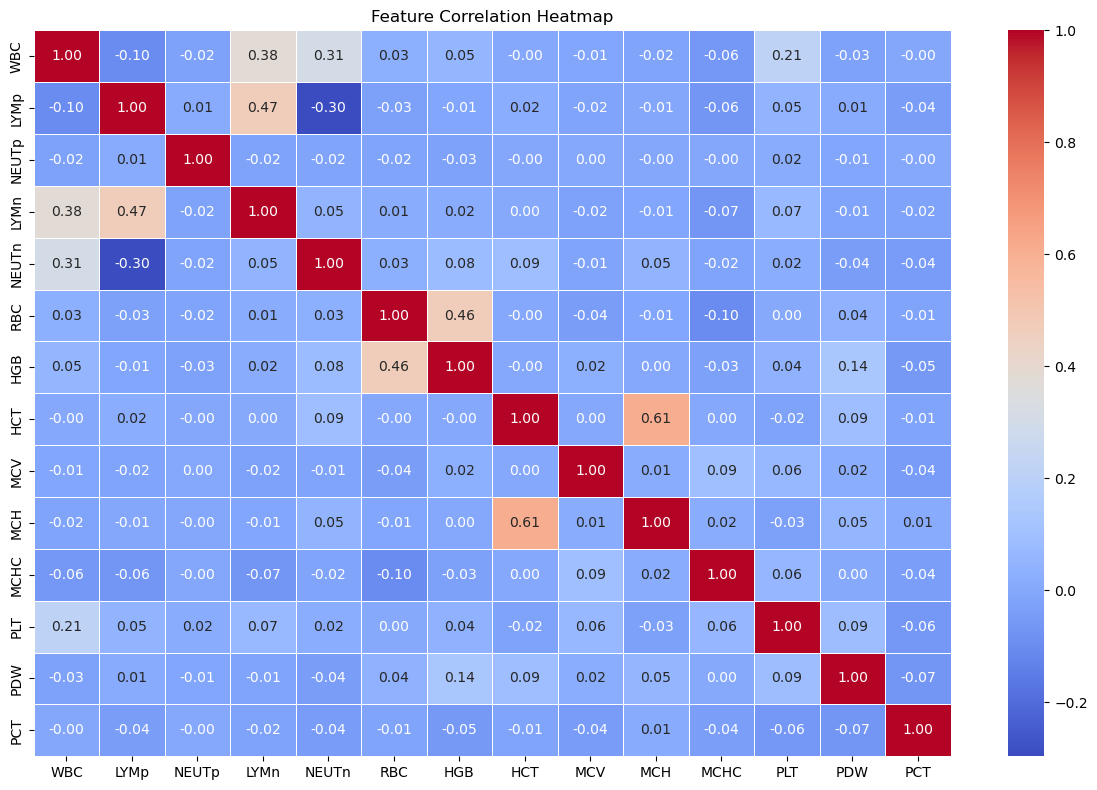

In [20]:
print("\n── Feature Statistics ──────────────────────────────────")
print(X.describe().round(2))
 
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

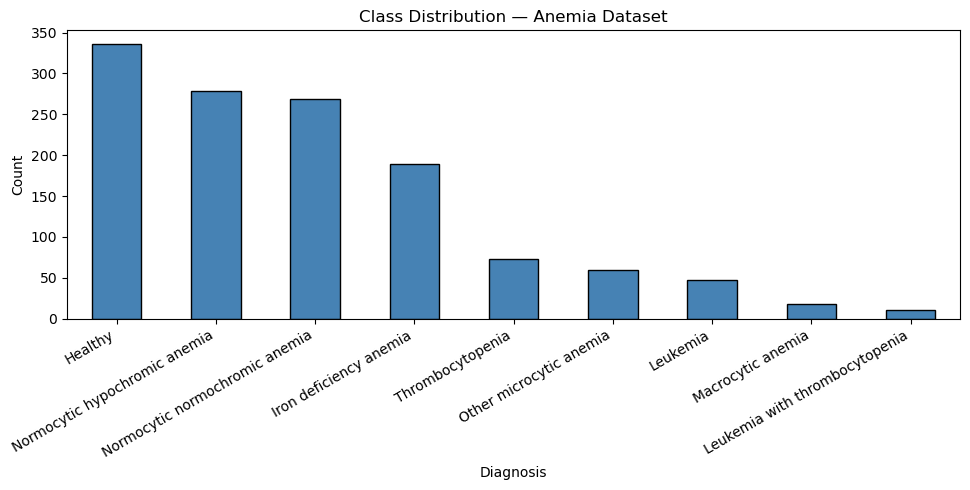

In [21]:
plt.figure(figsize=(10, 5))
df["Diagnosis"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Class Distribution — Anemia Dataset")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y       # keeps class ratio in both splits
)

In [14]:
print(f"\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print("Train distribution (before SMOTE):", Counter(y_train))


Train: 1024 samples  |  Test: 257 samples
Train distribution (before SMOTE): Counter({0: 269, 5: 223, 6: 215, 1: 151, 8: 58, 7: 47, 2: 38, 4: 14, 3: 9})


In [15]:
smote = SMOTE(
    sampling_strategy="not majority",   # upsample everything except the largest class
    random_state=42,
    k_neighbors=3          # use 3 neighbours for very small classes (Leukemia+Thrombo)
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
print("Train distribution (after SMOTE) :", Counter(y_train_res))

Train distribution (after SMOTE) : Counter({0: 269, 5: 269, 7: 269, 1: 269, 4: 269, 6: 269, 2: 269, 8: 269, 3: 269})


In [16]:
rf = RandomForestClassifier(
    n_estimators      = 500,       # more trees = better stability
    max_depth         = None,      # let trees grow fully (RF handles overfitting via bagging)
    min_samples_split = 4,         # don't split nodes with fewer than 4 samples
    min_samples_leaf  = 2,         # each leaf needs at least 2 samples
    max_features      = "sqrt",    # standard for classification
    class_weight      = "balanced",# extra weight on minority classes
    n_jobs            = -1,        # use all CPU cores
    random_state      = 42,
    oob_score         = True       # out-of-bag score — free internal validation
)

In [17]:
rf.fit(X_train_res, y_train_res)
print(f"\nOut-of-Bag Score : {rf.oob_score_:.4f}")
 
# Stratified cross-validation on resampled data
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1   = cross_val_score(rf, X_train_res, y_train_res, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-Fold CV Macro F1 : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")


Out-of-Bag Score : 0.9963
5-Fold CV Macro F1 : 0.9950 ± 0.0048


In [18]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1   = cross_val_score(rf, X_train_res, y_train_res, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-Fold CV Macro F1 : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

5-Fold CV Macro F1 : 0.9950 ± 0.0048


In [19]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)
 
print("\n── Classification Report ──────────────────────────────────")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=4
))


── Classification Report ──────────────────────────────────
                                precision    recall  f1-score   support

                       Healthy     1.0000    1.0000    1.0000        67
        Iron deficiency anemia     0.9737    0.9737    0.9737        38
                      Leukemia     1.0000    1.0000    1.0000         9
Leukemia with thrombocytopenia     1.0000    1.0000    1.0000         2
             Macrocytic anemia     1.0000    1.0000    1.0000         4
 Normocytic hypochromic anemia     0.9825    1.0000    0.9912        56
Normocytic normochromic anemia     1.0000    1.0000    1.0000        54
       Other microcytic anemia     1.0000    0.9167    0.9565        12
              Thrombocytopenia     1.0000    1.0000    1.0000        15

                      accuracy                         0.9922       257
                     macro avg     0.9951    0.9878    0.9913       257
                  weighted avg     0.9923    0.9922    0.9922       257



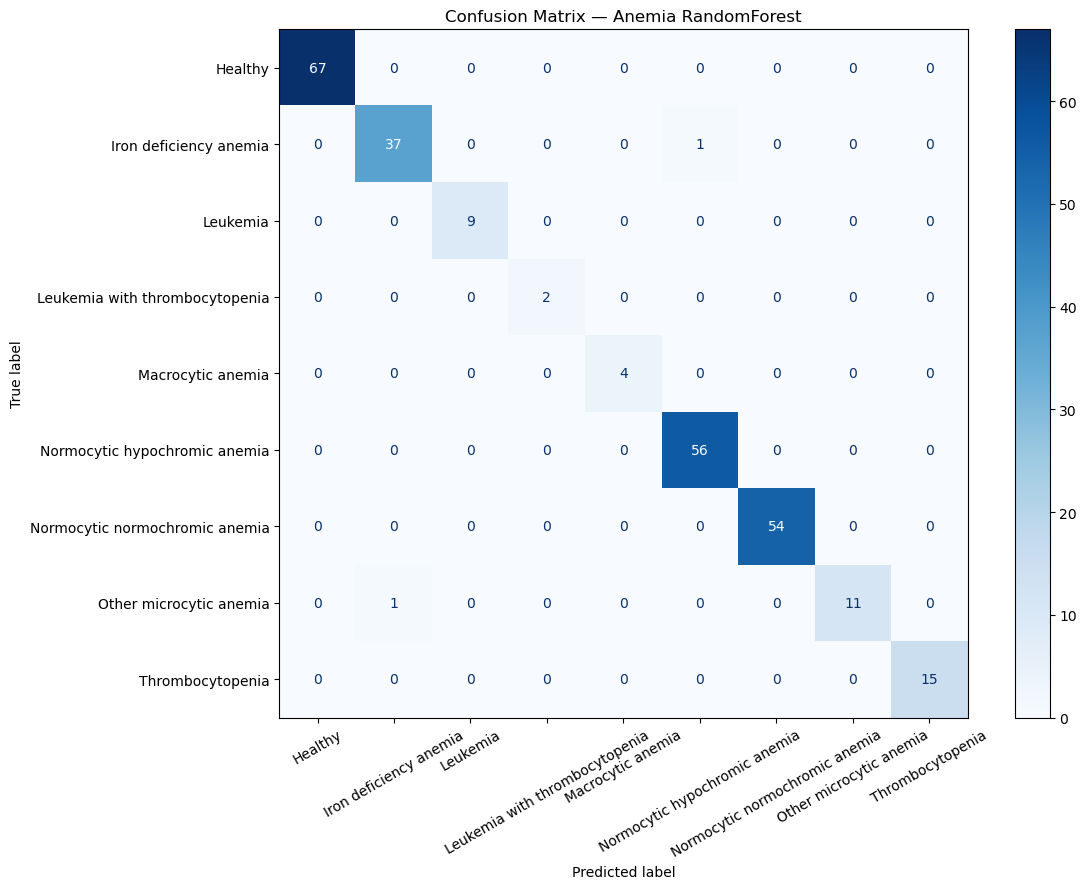

In [22]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 9))
cm      = confusion_matrix(y_test, y_pred)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=30)
plt.title("Confusion Matrix — Anemia RandomForest")
plt.tight_layout()
plt.show()

In [23]:
import joblib

joblib.dump(rf,     "../models/anemia_rf_model.pkl")
joblib.dump(scaler, "../models/anemia_scaler.pkl")
joblib.dump(le,     "../models/anemia_label_encoder.pkl")

['../models/anemia_label_encoder.pkl']